# D2-04 Spatial matching and fallback logic

This notebook focuses on the geography-matching logic used by `edges` once a method file and an inventory are already in place.


## Learning goals

After this notebook, you should be able to:

- explain why spatial matching is needed in regionalised LCIA
- distinguish direct, aggregate, dynamic, contained, and global fallback mapping
- predict which matching strategy should apply in simple geography cases
- identify the helper methods in `edges` that extend matching beyond direct hits


## Background references

- Sacchi, R., Menacho, A. H., Seitfudem, G., Agez, M., Schlesinger-Martinat, J., Koyamparambath, A., Saldivar, J. S., Loubet, P., & Bauer, C. (2025). Contextual LCIA without the overhead: an exchange-based framework for flexible impact assessment. *The International Journal of Life Cycle Assessment, 30*(12), 3087-3101. https://doi.org/10.1007/s11367-025-02551-7


## 1) Why matching logic is needed

A method file may define CFs for `FR`, `RER`, or `GLO`, while the inventory can contain exchanges located in `FR`, `ES`, `CA-QC`, or dynamic locations such as `RoW`. `edges` therefore needs a transparent sequence of matching rules.

In [1]:
import json
from pathlib import Path

import pandas as pd
pd.set_option('display.max_colwidth', None)

example_2_path = Path('/Users/romain/GitHub/barcelona-regionalized-lcia/tutorials/DAY 2/assets/edges_examples/lcia_example_2.json')
data = json.loads(example_2_path.read_text())

pd.DataFrame([
    {
        'supplier name': exc['supplier'].get('name'),
        'consumer location': exc['consumer'].get('location'),
        'value': exc['value'],
    }
    for exc in data['exchanges']
])


,supplier name,consumer location,value
0,Carbon dioxide,CH,1.0
1,Carbon dioxide,FR,2.0
2,Carbon dioxide,RER,3.0


## 2) The main matching strategies in `edges`

The four main mapping strategies described in the questionnaire are complemented by a global fallback for the remaining eligible exchanges.

In [2]:
mapping_rules = pd.DataFrame([
    {
        'rule': 'direct mapping',
        'example': 'FR -> FR',
        'idea': 'The CF exists for the exact same location as the exchange.',
    },
    {
        'rule': 'aggregate-region mapping',
        'example': 'ES -> RER',
        'idea': 'A broader regional factor is used when the exchange location sits inside an aggregate geography such as RER.',
    },
    {
        'rule': 'dynamic-location mapping',
        'example': 'RoW -> average over remaining country CFs',
        'idea': 'For dynamic locations such as RoW, `edges` starts from the country CFs available in the method and removes countries already represented explicitly in the inventory.',
    },
    {
        'rule': 'contained-location mapping',
        'example': 'CA-QC -> CA',
        'idea': 'A subregion inherits the factor of a containing location.',
    },
    {
        'rule': 'global fallback',
        'example': 'XX -> GLO',
        'idea': 'A global factor is used when no more specific match can be applied.',
    },
])
mapping_rules

,rule,example,idea
0,direct mapping,FR -> FR,The CF exists for the exact same location as the exchange.
1,aggregate-region mapping,ES -> RER,A broader regional factor is used when the exchange location sits inside an aggregate geography such as RER.
2,dynamic-location mapping,RoW -> average over remaining country CFs,"For dynamic locations such as RoW, `edges` starts from the country CFs available in the method and removes countries already represented explicitly in the inventory."
3,contained-location mapping,CA-QC -> CA,A subregion inherits the factor of a containing location.
4,global fallback,XX -> GLO,A global factor is used when no more specific match can be applied.


## Checkpoint 1

Predict which mapping strategy should apply in each row.


In [3]:
prediction_table = pd.DataFrame([
    {'inventory location': 'FR', 'available CF locations': 'FR, RER, GLO', 'predicted rule': ''},
    {'inventory location': 'ES', 'available CF locations': 'RER, GLO', 'predicted rule': ''},
    {'inventory location': 'RoW', 'available CF locations': 'AU, BR, CA, DZ, GLO', 'predicted rule': ''},
    {'inventory location': 'CA-QC', 'available CF locations': 'CA, GLO', 'predicted rule': ''},
    {'inventory location': 'XX', 'available CF locations': 'GLO', 'predicted rule': ''},
])
prediction_table

,inventory location,available CF locations,predicted rule
0,FR,"FR, RER, GLO",
1,ES,"RER, GLO",
2,RoW,"AU, BR, CA, DZ, GLO",
3,CA-QC,"CA, GLO",
4,XX,GLO,


In [4]:
prediction_table = pd.DataFrame([
    {'inventory location': 'FR', 'available CF locations': 'FR, RER, GLO', 'predicted rule': 'direct mapping'},
    {'inventory location': 'ES', 'available CF locations': 'RER, GLO', 'predicted rule': 'aggregate-region mapping'},
    {'inventory location': 'RoW', 'available CF locations': 'AU, BR, CA, DZ, GLO', 'predicted rule': 'dynamic-location mapping'},
    {'inventory location': 'CA-QC', 'available CF locations': 'CA, GLO', 'predicted rule': 'contained-location mapping'},
    {'inventory location': 'XX', 'available CF locations': 'GLO', 'predicted rule': 'global fallback'},
])
prediction_table

,inventory location,available CF locations,predicted rule
0,FR,"FR, RER, GLO",direct mapping
1,ES,"RER, GLO",aggregate-region mapping
2,RoW,"AU, BR, CA, DZ, GLO",dynamic-location mapping
3,CA-QC,"CA, GLO",contained-location mapping
4,XX,GLO,global fallback


## 3) Which `edges` methods implement these steps?

The API mirrors the conceptual workflow quite closely. The diagram below is the usual sequence once `lci()` has built the inventory.

In [5]:
helper_methods = pd.DataFrame([
    {'method': 'map_exchanges()', 'role': 'Apply the direct matching rules encoded in the method definition.'},
    {'method': 'map_aggregate_locations()', 'role': 'Use broader static regions such as RER when exact matches are unavailable.'},
    {'method': 'map_dynamic_locations()', 'role': 'Build dynamic regions such as RoW from the remaining country CFs after explicit locations have been excluded.'},
    {'method': 'map_contained_locations()', 'role': 'Use factors for containing regions such as CA for CA-QC.'},
    {'method': 'map_remaining_locations_to_global()', 'role': 'Assign a global fallback to the remaining eligible exchanges.'},
])
helper_methods

,method,role
0,map_exchanges(),Apply the direct matching rules encoded in the method definition.
1,map_aggregate_locations(),Use broader static regions such as RER when exact matches are unavailable.
2,map_dynamic_locations(),Build dynamic regions such as RoW from the remaining country CFs after explicit locations have been excluded.
3,map_contained_locations(),Use factors for containing regions such as CA for CA-QC.
4,map_remaining_locations_to_global(),Assign a global fallback to the remaining eligible exchanges.


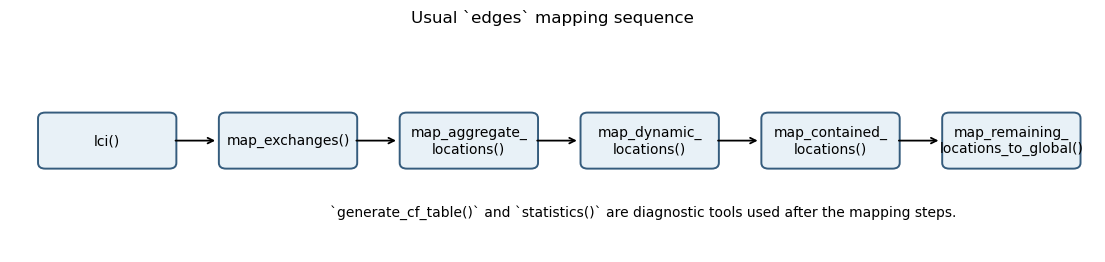

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    'lci()',
    'map_exchanges()',
    'map_aggregate_\nlocations()',
    'map_dynamic_\nlocations()',
    'map_contained_\nlocations()',
    'map_remaining_\nlocations_to_global()',
]

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.set_xlim(0, len(steps) * 2)
ax.set_ylim(0, 3)
ax.axis('off')

for i, step in enumerate(steps):
    x = 0.35 + i * 2
    box = FancyBboxPatch(
        (x, 1.2),
        1.45,
        0.7,
        boxstyle='round,pad=0.04,rounding_size=0.08',
        linewidth=1.4,
        edgecolor='#355C7D',
        facecolor='#E8F1F7',
    )
    ax.add_patch(box)
    ax.text(x + 0.725, 1.55, step, ha='center', va='center', fontsize=10)
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 1.95, 1.55), xytext=(x + 1.45, 1.55), arrowprops=dict(arrowstyle='->', lw=1.3))

ax.text(7, 0.55, '`generate_cf_table()` and `statistics()` are diagnostic tools used after the mapping steps.', ha='center', va='center', fontsize=10)
plt.title('Usual `edges` mapping sequence', pad=10)
plt.show()

## 4) Use `Geomatcher` to inspect aggregate and contained geographies

Before discussing dynamic `RoW`, it helps to isolate the easier cases:

- `ES -> RER` for an aggregate region
- `CA-QC -> CA` for a contained geography

In this section, you query `Geomatcher` directly to explain these static topology relationships.

In [7]:
from contextlib import redirect_stderr, redirect_stdout
import io

from constructive_geometries import Geomatcher

geo = Geomatcher()


def _quiet_geo(method_name, location):
    sink = io.StringIO()
    try:
        with redirect_stdout(sink), redirect_stderr(sink):
            return list(
                getattr(geo, method_name)(
                    location,
                    include_self=False,
                    exclusive=False if method_name == 'within' else True,
                    biggest_first=False,
                )
            )
    except KeyError:
        return None


def _labels(items):
    return [item[1] if isinstance(item, tuple) else str(item) for item in items]


def parents_of(location, limit=12):
    result = _quiet_geo('within', location)
    return [] if result is None else _labels(result)[:limit]


def children_of(location, limit=12):
    result = _quiet_geo('contained', location)
    return [] if result is None else _labels(result)[:limit]


def is_known(location):
    return _quiet_geo('within', location) is not None

Start by looking at both directions of the topology query:

- `within(location)` gives broader regions that contain a location.
- `contained(location)` gives finer subregions contained in a region.

In [8]:
pd.DataFrame([
    {
        'location': location,
        "within(location)": ', '.join(parents_of(location)) or '(none)',
        "contained(location)": ', '.join(children_of(location)) or '(none)',
    }
    for location in ['ES', 'CA-QC', 'BR', 'RER', 'CA']
])

,location,within(location),contained(location)
0,ES,"UN-SEUROPE, UCTE without Germany and France, UCTE without France, UCTE without Germany, IAI Area, EU27 & EFTA, UCTE, RER w/o AT+BE+CH+DE+FR+IT, RER w/o DE+NL+NO+RU, Europe without NORDEL (NCPA), ENTSO-E, RER w/o DE+NL+NO, RER w/o DE+NL+RU",Canary Islands
1,CA-QC,"Québec, HQ distribution network, NPCC, Canada without Alberta, CA, IAI Area, North America, CUSMA/T-MEC/USMCA, NAFTA, RNA, UN-AMERICAS, GLO","Québec, HQ distribution network"
2,BR,"IAI Area, South America, UN-SAMERICA, RLA, UN-AMERICAS, GLO","BR-AC, BR-AL, BR-AM, BR-CE, BR-DF, BR-GO, BR-MG, BR-MS, BR-MT, BR-PB, BR-PI, BR-RO"
3,RER,"UN-EUROPE, GLO","GI, JE, MC, VA, IM, GG, LU, AD, BY, Canary Islands, SK, SM"
4,CA,"IAI Area, North America, CUSMA/T-MEC/USMCA, NAFTA, RNA, UN-AMERICAS, GLO","CA-AB, CA-MB, CA-PE, CA-SK, CA-ON, CA-YK, CA-NB, CA-NS, CA-QC, CA-NT, CA-NF, CA-BC"


The next map stays at the **country** level. It helps visualize the aggregate region `RER` and shows that example inventory locations like `ES` and `IT` sit inside that broader regional CF geography.

Two topology subtleties matter here:

- in `Geomatcher`, Spain is split so that `Canary Islands` is treated separately, so we re-add `ES` explicitly to make mainland Spain visible;
- `Russia (Europe)` is not a sovereign-country polygon, and `country_converter` maps it to `RUS`, which would incorrectly paint all of Russia.

For a country-level map, we therefore re-add `ES` but skip `Canary Islands` and `Russia (Europe)`.

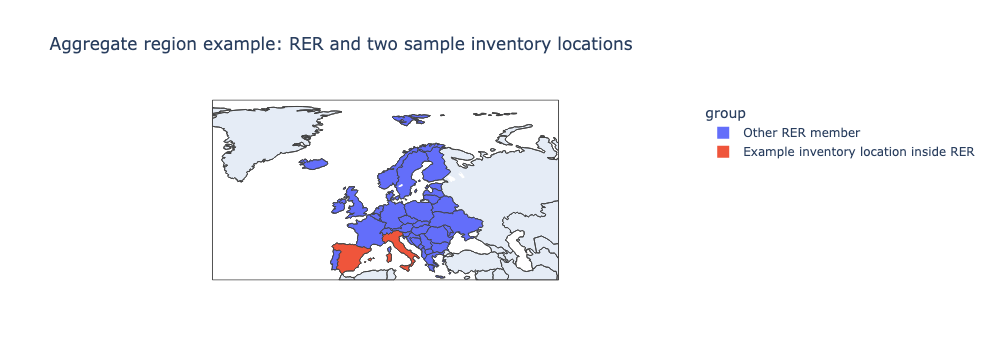

In [9]:
import country_converter as coco
import plotly.express as px

COUNTRY_LEVEL_EXCLUSIONS = {'Canary Islands', 'Russia (Europe)'}


def to_iso3(location):
    sink = io.StringIO()
    with redirect_stdout(sink), redirect_stderr(sink):
        iso3 = coco.convert(names=location, to='ISO3', not_found=None)
    if not iso3 or iso3 == location or len(str(iso3)) != 3:
        return None
    return str(iso3)


def plot_country_groups(groups, title):
    rows = []
    skipped = []
    for location, group in groups.items():
        if location in COUNTRY_LEVEL_EXCLUSIONS:
            skipped.append(f'{location} (cannot be drawn faithfully on a country-level map)')
            continue
        iso3 = to_iso3(location)
        if iso3 is None:
            skipped.append(location)
            continue
        rows.append({'location': location, 'iso3': iso3, 'group': group})
    frame = pd.DataFrame(rows)
    if frame.empty:
        print('No mappable country-level locations found.')
    else:
        fig = px.choropleth(
            frame,
            locations='iso3',
            color='group',
            hover_name='location',
            projection='natural earth',
            title=title,
        )
        fig.update_geos(showcoastlines=True, showcountries=True, fitbounds='locations')
        fig.show()
    if skipped:
        print('Not shown on the country-level map:', skipped)


rer_members = sorted(set(children_of('RER', limit=500)))
rer_members_for_map = sorted((set(rer_members) - COUNTRY_LEVEL_EXCLUSIONS) | {'ES'})
rer_map_groups = {
    location: ('Example inventory location inside RER' if location in {'ES', 'IT'} else 'Other RER member')
    for location in rer_members_for_map
}
plot_country_groups(rer_map_groups, 'Aggregate region example: RER and two sample inventory locations')

## Checkpoint 2

Use the table and the map above to fill in the missing answers, then run the next cell to check them.

In [10]:
geomatcher_answers = pd.DataFrame([
    {'location': 'ES', 'question': 'One broader region returned by within(ES)', 'your answer': ''},
    {'location': 'CA-QC', 'question': 'Containing country used to explain CA-QC', 'your answer': ''},
    {'location': 'BR', 'question': 'Is BR inside RER? (True/False)', 'your answer': ''},
    {'location': 'XX', 'question': 'Is XX known to Geomatcher? (True/False)', 'your answer': ''},
])
geomatcher_answers

,location,question,your answer
0,ES,One broader region returned by within(ES),
1,CA-QC,Containing country used to explain CA-QC,
2,BR,Is BR inside RER? (True/False),
3,XX,Is XX known to Geomatcher? (True/False),


In [11]:
expected_geomatcher = {
    ('ES', 'One broader region returned by within(ES)'): 'RER',
    ('CA-QC', 'Containing country used to explain CA-QC'): 'CA',
    ('BR', 'Is BR inside RER? (True/False)'): 'FALSE',
    ('XX', 'Is XX known to Geomatcher? (True/False)'): 'FALSE',
}


def grade_geomatcher_answers(answer_table):
    rows = []
    for _, row in answer_table.iterrows():
        expected = expected_geomatcher[(row['location'], row['question'])]
        parsed = str(row['your answer']).strip().upper()
        rows.append(
            {
                'location': row['location'],
                'question': row['question'],
                'interpreted answer': parsed,
                'expected': expected,
                'correct?': parsed == expected,
            }
        )
    return pd.DataFrame(rows)


grade_geomatcher_answers(geomatcher_answers)

,location,question,interpreted answer,expected,correct?
0,ES,One broader region returned by within(ES),,RER,False
1,CA-QC,Containing country used to explain CA-QC,,CA,False
2,BR,Is BR inside RER? (True/False),,FALSE,False
3,XX,Is XX known to Geomatcher? (True/False),,FALSE,False


In [12]:
geomatcher_answers = pd.DataFrame([
    {'location': 'ES', 'question': 'One broader region returned by within(ES)', 'your answer': 'RER'},
    {'location': 'CA-QC', 'question': 'Containing country used to explain CA-QC', 'your answer': 'CA'},
    {'location': 'BR', 'question': 'Is BR inside RER? (True/False)', 'your answer': 'False'},
    {'location': 'XX', 'question': 'Is XX known to Geomatcher? (True/False)', 'your answer': 'False'},
])
grade_geomatcher_answers(geomatcher_answers)

,location,question,interpreted answer,expected,correct?
0,ES,One broader region returned by within(ES),RER,RER,True
1,CA-QC,Containing country used to explain CA-QC,CA,CA,True
2,BR,Is BR inside RER? (True/False),FALSE,FALSE,True
3,XX,Is XX known to Geomatcher? (True/False),FALSE,FALSE,True


## 5) Dynamic `RoW` on a real BAFU activity

`RoW` is different from `RER` or `CA`. It is not a fixed region in the method file. Instead, `edges` builds it dynamically from the **country CFs** that remain available after excluding same-product locations already present in the inventory.

Here we use `Natural gas, burned in gas turbine` at location `RoW` for two complementary views:

- the **actual** `edges` behavior with a country-level teaching method;
- a **counterfactual teaching view** where we ignore aggregate inventory locations and ask a simpler question: which countries would remain in `RoW` if we excluded only the explicit same-product country datasets?

This teaching simplification matches the structure of `edges` method files, which only contain country CFs here.


In [13]:
import json
import tempfile
from pathlib import Path

import bw2data as bd
import numpy as np
from IPython.display import display
from edges import EdgeLCIA

/opt/homebrew/Caskroom/miniforge/base/envs/bw/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Start by locating the activity and listing the same-product locations already present in the inventory.

In [14]:
bd.projects.set_current('barcelona-rlcia-2026')
db_name = next((name for name in sorted(bd.databases) if name.startswith('bafu')), 'bafu')

db = bd.Database(db_name)

bafu_activity = next(
    (
        act for act in db
        if act['name'].startswith("Natural gas, burned in gas turbine")
        and act.get('location') == 'RoW'
    ),
    None,
)

if bafu_activity is None:
    print('The expected RoW natural-gas activity was not found in this BAFU database.')
else:
    display(
        pd.Series(
            {
                'database': db_name,
                'name': bafu_activity['name'],
                'location': bafu_activity.get('location'),
                'reference product': bafu_activity.get('reference product'),
                'unit': bafu_activity.get('unit'),
            }
        )
    )

database                                           bafu
name                 Natural gas, burned in gas turbine
location                                            RoW
reference product    Natural gas, burned in gas turbine
unit                                          megajoule
dtype: object

In [15]:
if bafu_activity is None:
    print('No BAFU activity available for this demonstration.')
else:
    probe_method = {
        'name': 'Dynamic RoW probe method',
        'version': '1.0',
        'unit': 'kg CO2-eq',
        'description': 'Temporary method used only to inspect same-product locations in the inventory.',
        'exchanges': [
            {
                'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
                'consumer': {'matrix': 'technosphere', 'location': 'CH'},
                'value': 1.0,
                'weight': 1.0,
            }
        ],
    }
    probe_path = Path(tempfile.gettempdir()) / 'edges_dynamic_row_probe.json'
    probe_path.write_text(json.dumps(probe_method, indent=2))

    probe_lca = EdgeLCIA(
        demand={bafu_activity: 1},
        method=('demo', 'dynamic-row-probe'),
        filepath=str(probe_path),
    )
    probe_lca.lci()

    same_product_locations = sorted(
        {
            flow.get('location')
            for flow in probe_lca.technosphere_flows
            if flow.get('name') == bafu_activity['name']
            and flow.get('reference product') == bafu_activity['reference product']
            and isinstance(flow.get('location'), str)
            and flow.get('location') not in {'RoW', 'RoE'}
        }
    )

    explicit_country_locations = [
        loc for loc in same_product_locations if len(loc) == 2 and loc.isupper() and to_iso3(loc) is not None
    ]
    aggregate_locations = [loc for loc in same_product_locations if loc not in explicit_country_locations]

    world_country_codes = [
        code
        for code in sorted(coco.CountryConverter().data['ISO2'].dropna().astype(str).unique())
        if len(code) == 2 and to_iso3(code) is not None
    ]
    dynamic_row_pool_counterfactual = [
        code for code in world_country_codes
        if code not in explicit_country_locations
    ]

    display(
        pd.DataFrame([
            {
                'explicit same-product country datasets in the inventory': len(explicit_country_locations),
                'aggregate same-product locations in the inventory': ', '.join(aggregate_locations),
                'countries remaining in the teaching RoW pool': len(dynamic_row_pool_counterfactual),
            }
        ])
    )


,explicit same-product country datasets in the inventory,aggregate same-product locations in the inventory,countries remaining in the teaching RoW pool
0,63,"Europe without Switzerland, GLO, RER",187


Two different interpretations are now useful:

1. **Actual `edges` behavior**: because `GLO` is one of the same-product locations in the inventory, the dynamic `RoW` pool can collapse.
2. **Counterfactual teaching view**: if we ignore `GLO` just for the map, we can still visualize the distinction between countries with explicit datasets and countries that would otherwise remain in `RoW`.

The next cells show both on purpose.

In [16]:
if bafu_activity is None:
    print('No BAFU activity available for this demonstration.')
else:
    country_factors = {code: 30.0 for code in world_country_codes}

    dynamic_method = {
        'name': 'Dynamic RoW teaching example',
        'version': '1.0',
        'unit': 'kg CO2-eq',
        'description': 'Teaching method with one country CF for every country, used to contrast actual and teaching-view RoW behavior.',
        'exchanges': [
            {
                'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
                'consumer': {'matrix': 'technosphere', 'location': loc},
                'value': value,
                'weight': 1.0,
            }
            for loc, value in country_factors.items()
        ],
    }

    dynamic_row_path = Path(tempfile.gettempdir()) / 'edges_dynamic_row_teaching_method.json'
    dynamic_row_path.write_text(json.dumps(dynamic_method, indent=2))

    teaching_method_table = pd.DataFrame([
        {
            'group': 'explicit same-product countries already in the inventory',
            'count': len(explicit_country_locations),
            'example locations': ', '.join(explicit_country_locations[:12]) + (' ...' if len(explicit_country_locations) > 12 else ''),
        },
        {
            'group': 'countries remaining in the teaching RoW pool',
            'count': len(dynamic_row_pool_counterfactual),
            'example locations': ', '.join(dynamic_row_pool_counterfactual[:12]) + (' ...' if len(dynamic_row_pool_counterfactual) > 12 else ''),
        },
    ])
    display(teaching_method_table)


,group,count,example locations
0,explicit same-product countries already in the inventory,63,"AE, AO, AR, AT, AU, AZ, BE, BG, BO, BR, CA, CH ..."
1,countries remaining in the teaching RoW pool,187,"AD, AF, AG, AI, AL, AM, AQ, AS, AW, AX, BA, BB ..."


Now compare the real and the counterfactual interpretations:

1. run `edges` exactly as implemented, with the real inventory still containing `GLO`;
2. check whether `RoW` gets a CF in that real run;
3. then build a country-level map that ignores `GLO` only for teaching purposes.

In [17]:
if bafu_activity is None:
    print('No BAFU activity available for this demonstration.')
else:
    row_lca = EdgeLCIA(
        demand={bafu_activity: 1},
        method=('demo', 'dynamic-row'),
        filepath=str(dynamic_row_path),
    )
    row_lca.lci()
    row_lca.map_exchanges()
    row_lca.map_aggregate_locations()
    row_lca.map_dynamic_locations()
    row_lca.evaluate_cfs()
    row_lca.lcia()

    cf_table = row_lca.generate_cf_table(include_unmatched=True)
    carbon_rows = cf_table[
        (cf_table['consumer name'] == bafu_activity['name'])
        & (cf_table['supplier name'].str.contains('Carbon dioxide', case=False, na=False))
    ][['consumer location', 'CF']].drop_duplicates()

    actual_non_row_matches = sorted(
        carbon_rows.loc[
            carbon_rows['CF'].notna() & (carbon_rows['consumer location'] != 'RoW'),
            'consumer location',
        ].tolist()
    )
    actual_row_cf = None
    if ((carbon_rows['consumer location'] == 'RoW') & carbon_rows['CF'].notna()).any():
        actual_row_cf = round(
            float(
                carbon_rows.loc[
                    (carbon_rows['consumer location'] == 'RoW') & carbon_rows['CF'].notna(),
                    'CF',
                ].iloc[0]
            ),
            3,
        )

    comparison = pd.DataFrame([
        {'item': 'Explicit same-product country datasets already in the inventory', 'value': len(explicit_country_locations)},
        {'item': 'Actual non-RoW matches found by `edges`', 'value': len(actual_non_row_matches)},
        {'item': 'Actual RoW CF in the real run', 'value': actual_row_cf if actual_row_cf is not None else '(none; aggregate inventory coverage collapses the dynamic pool)'},
        {'item': 'Countries remaining in the teaching RoW pool', 'value': len(dynamic_row_pool_counterfactual)},
    ])
    display(comparison)
    display(pd.DataFrame([
        {
            'actual non-RoW matches found by `edges`': ', '.join(actual_non_row_matches[:20]) + (' ...' if len(actual_non_row_matches) > 20 else ''),
            'countries remaining in the teaching RoW pool': ', '.join(dynamic_row_pool_counterfactual[:20]) + (' ...' if len(dynamic_row_pool_counterfactual) > 20 else ''),
        }
    ]))


,item,value
0,Explicit same-product country datasets already in the inventory,63
1,Actual non-RoW matches found by `edges`,57
2,Actual RoW CF in the real run,(none; aggregate inventory coverage collapses the dynamic pool)
3,Countries remaining in the teaching RoW pool,187


,actual non-RoW matches found by `edges`,countries remaining in the teaching RoW pool
0,"AE, AO, AR, AT, AU, AZ, BE, BG, BO, BR, CA, CH, CN, CO, CZ, DE, DK, DZ, EG, ES ...","AD, AF, AG, AI, AL, AM, AQ, AS, AW, AX, BA, BB, BD, BF, BH, BI, BJ, BL, BM, BN ..."


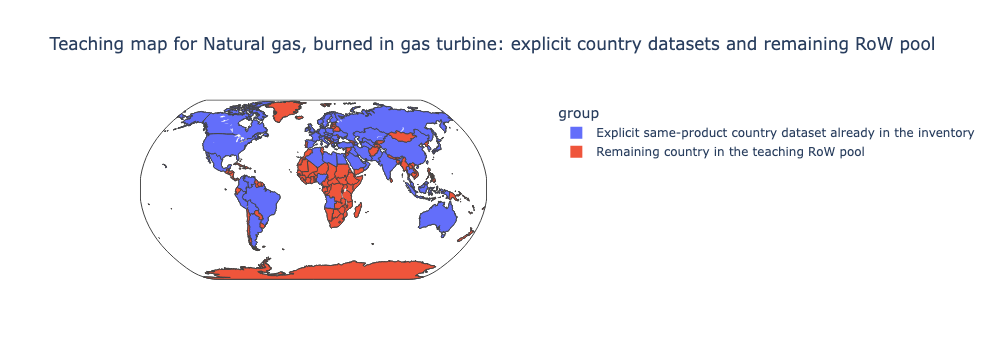

Aggregate inventory locations not shown on the country-level map: Europe without Switzerland, GLO, RER


In [18]:
if bafu_activity is None:
    print('No BAFU activity available for this demonstration.')
else:
    row_map_groups = {
        **{loc: 'Explicit same-product country dataset already in the inventory' for loc in explicit_country_locations},
        **{loc: 'Remaining country in the teaching RoW pool' for loc in dynamic_row_pool_counterfactual},
    }
    plot_country_groups(
        row_map_groups,
        'Teaching map for Natural gas, burned in gas turbine: explicit country datasets and remaining RoW pool'
    )
    print('Aggregate inventory locations not shown on the country-level map:', ', '.join(aggregate_locations))


## Checkpoint 3

Use the real BAFU run above to answer four questions:

- How many explicit same-product country datasets already exist in the inventory for this product family?
- Why does actual `RoW` collapse in the real run?
- How many countries would remain in `RoW` if `GLO` were ignored for teaching purposes?
- What does the counterfactual map help you see that the real run hides?

In [19]:
dynamic_row_answers = pd.DataFrame([
    {'question': 'Number of explicit same-product country datasets already in the inventory', 'your answer': ''},
    {'question': 'Why is the actual RoW CF still missing in the real run?', 'your answer': ''},
    {'question': 'Number of countries remaining in the teaching RoW pool', 'your answer': ''},
    {'question': 'What does the teaching map make visible?', 'your answer': ''},
])
dynamic_row_answers


,question,your answer
0,Number of explicit same-product country datasets already in the inventory,
1,Why is the actual RoW CF still missing in the real run?,
2,Number of countries remaining in the teaching RoW pool,
3,What does the teaching map make visible?,


In [20]:
def grade_dynamic_row_answers(answer_table):
    if 'dynamic_row_pool_counterfactual' not in globals():
        return pd.DataFrame([{'status': 'Run the dynamic RoW example cell first.'}])

    expected = {
        'Number of explicit same-product country datasets already in the inventory': len(explicit_country_locations),
        'Why is the actual RoW CF still missing in the real run?': 'because aggregate inventory locations are present in the same-product family',
        'Number of countries remaining in the teaching RoW pool': len(dynamic_row_pool_counterfactual),
    }
    rows = []
    for _, row in answer_table.iterrows():
        question = row['question']
        answer = str(row['your answer']).strip()
        if question == 'What does the teaching map make visible?':
            rows.append(
                {
                    'question': question,
                    'interpreted answer': answer,
                    'expected': 'free-text explanation',
                    'correct?': '(manual check)',
                }
            )
            continue

        if question == 'Why is the actual RoW CF still missing in the real run?':
            parsed = answer.lower()
            ok = 'aggregate' in parsed or 'glo' in parsed or 'rer' in parsed
        else:
            try:
                parsed = int(float(answer))
            except Exception:
                parsed = None
            ok = parsed == expected[question]
        rows.append(
            {
                'question': question,
                'interpreted answer': parsed,
                'expected': expected[question],
                'correct?': ok,
            }
        )
    return pd.DataFrame(rows)


grade_dynamic_row_answers(dynamic_row_answers)


,question,interpreted answer,expected,correct?
0,Number of explicit same-product country datasets already in the inventory,None,63,False
1,Why is the actual RoW CF still missing in the real run?,,because aggregate inventory locations are present in the same-product family,False
2,Number of countries remaining in the teaching RoW pool,None,187,False
3,What does the teaching map make visible?,,free-text explanation,(manual check)


In [21]:
dynamic_row_answers = pd.DataFrame([
    {'question': 'Number of explicit same-product country datasets already in the inventory', 'your answer': len(explicit_country_locations)},
    {'question': 'Why is the actual RoW CF still missing in the real run?', 'your answer': 'Because aggregate inventory locations like GLO and RER are present in the same-product family.'},
    {'question': 'Number of countries remaining in the teaching RoW pool', 'your answer': len(dynamic_row_pool_counterfactual)},
    {'question': 'What does the teaching map make visible?', 'your answer': 'It separates countries with explicit same-product datasets from the countries that remain in the teaching RoW pool.'},
])
grade_dynamic_row_answers(dynamic_row_answers)


,question,interpreted answer,expected,correct?
0,Number of explicit same-product country datasets already in the inventory,63,63,True
1,Why is the actual RoW CF still missing in the real run?,because aggregate inventory locations like glo and rer are present in the same-product family.,because aggregate inventory locations are present in the same-product family,True
2,Number of countries remaining in the teaching RoW pool,187,187,True
3,What does the teaching map make visible?,It separates countries with explicit same-product datasets from the countries that remain in the teaching RoW pool.,free-text explanation,(manual check)


## Recap

After this notebook, you should now be able to:

- explain why spatial matching is needed in `edges`
- connect each conceptual matching rule to the corresponding helper method in the API
- query `Geomatcher` directly to explain aggregate and contained geographies
- explain why dynamic `RoW` is computed from the remaining country CFs instead of read as a fixed factor
- distinguish a real run where `RoW` collapses because `GLO` is present from a counterfactual map that ignores `GLO` for teaching purposes
- use simple maps to explain aggregate regions and dynamic-country pools